<a href="https://colab.research.google.com/github/SIVAPRASAD03/Quantum/blob/main/Single_Qubit_Gate_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single_Qubit_Gate_Explorer
Choose one gate, apply it to a qubit initially in $|0\rangle$, and view its circuit, Bloch sphere, and measurement probabilities.

In [6]:
# Install matplotlib,Qiskit,pylatexenc
!pip install -q qiskit pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 1.4 MB/s eta 0:00:00


Choose a gate (X, Y, Z, H, RY): RY
Enter the RY rotation angle theta (in radians): 1
Applied RY(1.000000) radians = 57.30 degrees
Quantum circuit:
   ┌───────┐
q: ┤ Ry(1) ├
   └───────┘
Final statevector: Statevector([0.87758256+0.j, 0.47942554+0.j],
            dims=(2,))
P(|0>) = 0.770151
P(|1>) = 0.229849
Bloch Sphere:


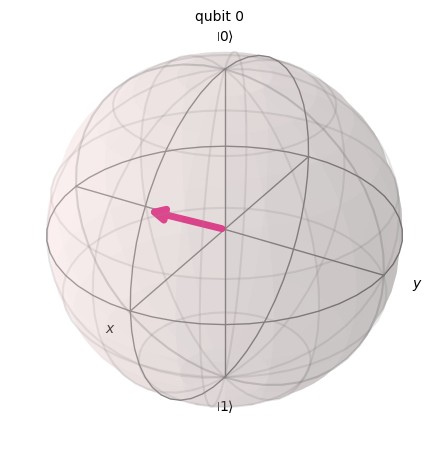

In [10]:
import math
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

gate = input('Choose a gate (X, Y, Z, H, RY): ').strip().upper()
valid_gates = {'X', 'Y', 'Z', 'H', 'RY'}

if gate not in valid_gates:
    raise ValueError('Invalid choice. Please run the cell again and enter X, Y, Z, H, or RY.')

circuit = QuantumCircuit(1)

if gate == 'X':
    circuit.x(0)
elif gate == 'Y':
    circuit.y(0)
elif gate == 'Z':
    circuit.z(0)
elif gate == 'H':
    circuit.h(0)
else:
    theta = float(input('Enter the RY rotation angle theta (in radians): '))
    circuit.ry(theta, 0)
    print(f'Applied RY({theta:.6f}) radians = {math.degrees(theta):.2f} degrees')

# No measurement is added: Statevector gives exact probabilities without collapsing the state.
final_state = Statevector.from_instruction(circuit)
probabilities = final_state.probabilities_dict()

print('Quantum circuit:')
print(circuit.draw(output='text'))

print('Final statevector:', final_state)
print(f"P(|0>) = {probabilities.get('0', 0.0):.6f}")
print(f"P(|1>) = {probabilities.get('1', 0.0):.6f}")

print('Bloch Sphere:')
plot_bloch_multivector(final_state)